In [ ]:
import json
import configparser

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from functools import lru_cache
from scipy.special import i1e, loggamma
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import ImageGrid

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['axes.unicode_minus'] = False

%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

In [147]:
m_0 = 1.0
M_0 = 1e30
N_0 = M_0 / m_0
lambda_0 = 1.0 / M_0

def rect_inches(fig, left, bottom, width, height):
    fw, fh = fig.get_size_inches()
    return [left/fw, bottom/fh, width/fw, height/fh]

def const_w1_logmass(data, tau, m0):

    m = data["par_size"]**3
    w = data["par_numr"]*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = "right")
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]

    g = 1.0 / (1.0 + tau / 2.0)
    k = np.ceil(10.0**x).astype(np.int64) - 1

    F_ana = np.zeros_like(x)
    valid = k >= 1
    F_ana[valid] = -np.expm1(k[valid]*np.log1p(-g) + np.log1p(k[valid]*g))

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_const(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_const/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = float(config["PARAMETERS"]["DT_OUT"])*int(config["PARAMETERS"]["LOG_BASE"])**frame

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)
    
    return const_w1_logmass(data, tau, m_0)

@lru_cache(maxsize = None)
def linear_mass_cdf(tau):

    x_eval = np.linspace(-0.5, 9.5, 4097)
    x_work = np.linspace(-12.0, 12.0, 65537)
    mu = 10.0**x_work

    g = np.exp(-tau)
    sqrt_1mg = np.sqrt(1.0 - g)
    arg = 2.0*mu*sqrt_1mg
    decay = g/(1.0 + sqrt_1mg)
    exponent = -mu*decay**2

    p_logmass = np.log(10.0)*mu*g*i1e(arg)*np.exp(exponent)/sqrt_1mg

    cdf_work = np.empty_like(x_work)
    cdf_work[0] = 0.0
    cdf_work[1:] = np.cumsum(0.5*(p_logmass[:-1] + p_logmass[1:])*np.diff(x_work))
    cdf_work /= cdf_work[-1]

    return np.interp(x_eval, x_work, cdf_work)

def linear_w1_logmass(data, tau, m0):

    m = data['par_size']**3
    w = data['par_numr']*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = 'right')
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]
    F_ana = linear_mass_cdf(float(tau))

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_linear(model):

    path_model = Path('/Users/jiaqingbi/Scratch/gamedev/test_linear')/model

    config = configparser.ConfigParser()
    config.read(path_model/'variables.txt')

    dtype = np.dtype([(name, value) for name, value in config['SWARM_DTYPE'].items()])

    snapshot = 4
    tau = snapshot*float(config['PARAMETERS']['DT_OUT'])
    data = np.fromfile(path_model/f'particle_{snapshot:05d}.dat', dtype = dtype)

    return linear_w1_logmass(data, tau, m0 = 1.0)

@lru_cache(maxsize = None)
def product_mass_cdf(tau, k_max = 100_000):

    probability = np.empty(k_max)

    # p_k = exp(-k*tau) * (k*tau)^(k-1) / k!
    probability[0] = np.exp(-tau)

    factor = tau*np.exp(-tau)

    for k in range(1, k_max):
        probability[k] = (probability[k - 1]*factor*np.exp((k - 1)*np.log1p(1.0/k)))

    return np.cumsum(probability)

def product_w1_logmass(data, tau, m0):

    m = data["par_size"]**3
    w = data["par_numr"]*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = "right")
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]

    k_below = np.ceil(10.0**x).astype(np.int64) - 1
    cdf = product_mass_cdf(float(tau))

    F_ana = np.zeros_like(x)
    valid = k_below >= 1
    F_ana[valid] = cdf[np.minimum(k_below[valid], len(cdf)) - 1]

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1_product(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_product/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + "variables.txt")

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = float(config["PARAMETERS"]["DT_OUT"])*frame

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)

    return product_w1_logmass(data, tau, m_0)

def get_mass (size): return size*size*size

def const_kernel (m, N_0, M_0, m_0, Lambda, t):
    h = 0.5*M_0*Lambda*t
    g = 1.0/(1.0+h)
    f = N_0*g*g*(1.0-g)**(m/m_0-1.0)
    return f*m*m / M_0 / m_0

def init_dist (m, N_0, M_0, m_0):
    f = N_0*np.exp(-m/m_0)/m_0
    return f*m*m / M_0 / m_0

def linear_kernel (m, N_0, M_0, m_0, Lambda, t):
    tau = M_0*Lambda*t
    g = np.exp(-tau)
    # Use exponentially scaled Bessel: i1e(x) = i1(x)*exp(-|x|)
    # This avoids overflow: i1(x)*exp(y) = i1e(x)*exp(x+y)
    arg = 2.0*m/m_0*np.sqrt(1.0-g)
    exponent = arg - m/m_0*(2.0-g)  # Combine exponentials
    f = N_0/m*(g/np.sqrt(1.0-g))*i1e(arg)*np.exp(exponent)
    return f*m*m / M_0 / m_0

def product_kernel (m, N_0, M_0, m_0, Lambda, t):
    eta = N_0*Lambda*t
    k = m / m_0
    # Work in log-space to avoid overflow
    # log(f) = log(N_0) + (k-1)*log(2*k) - log(k) - loggamma(k+1) + (k-1)*log(0.5*eta) - k*eta
    log_f = np.log(N_0) + (k-1.0)*np.log(2.0*k) - np.log(k) - loggamma(k+1.0) + (k-1.0)*np.log(0.5*eta) - k*eta
    # f*m*m = exp(log_f + 2*log(m))
    return np.exp(log_f + 2.0*np.log(m)) / M_0 / m_0

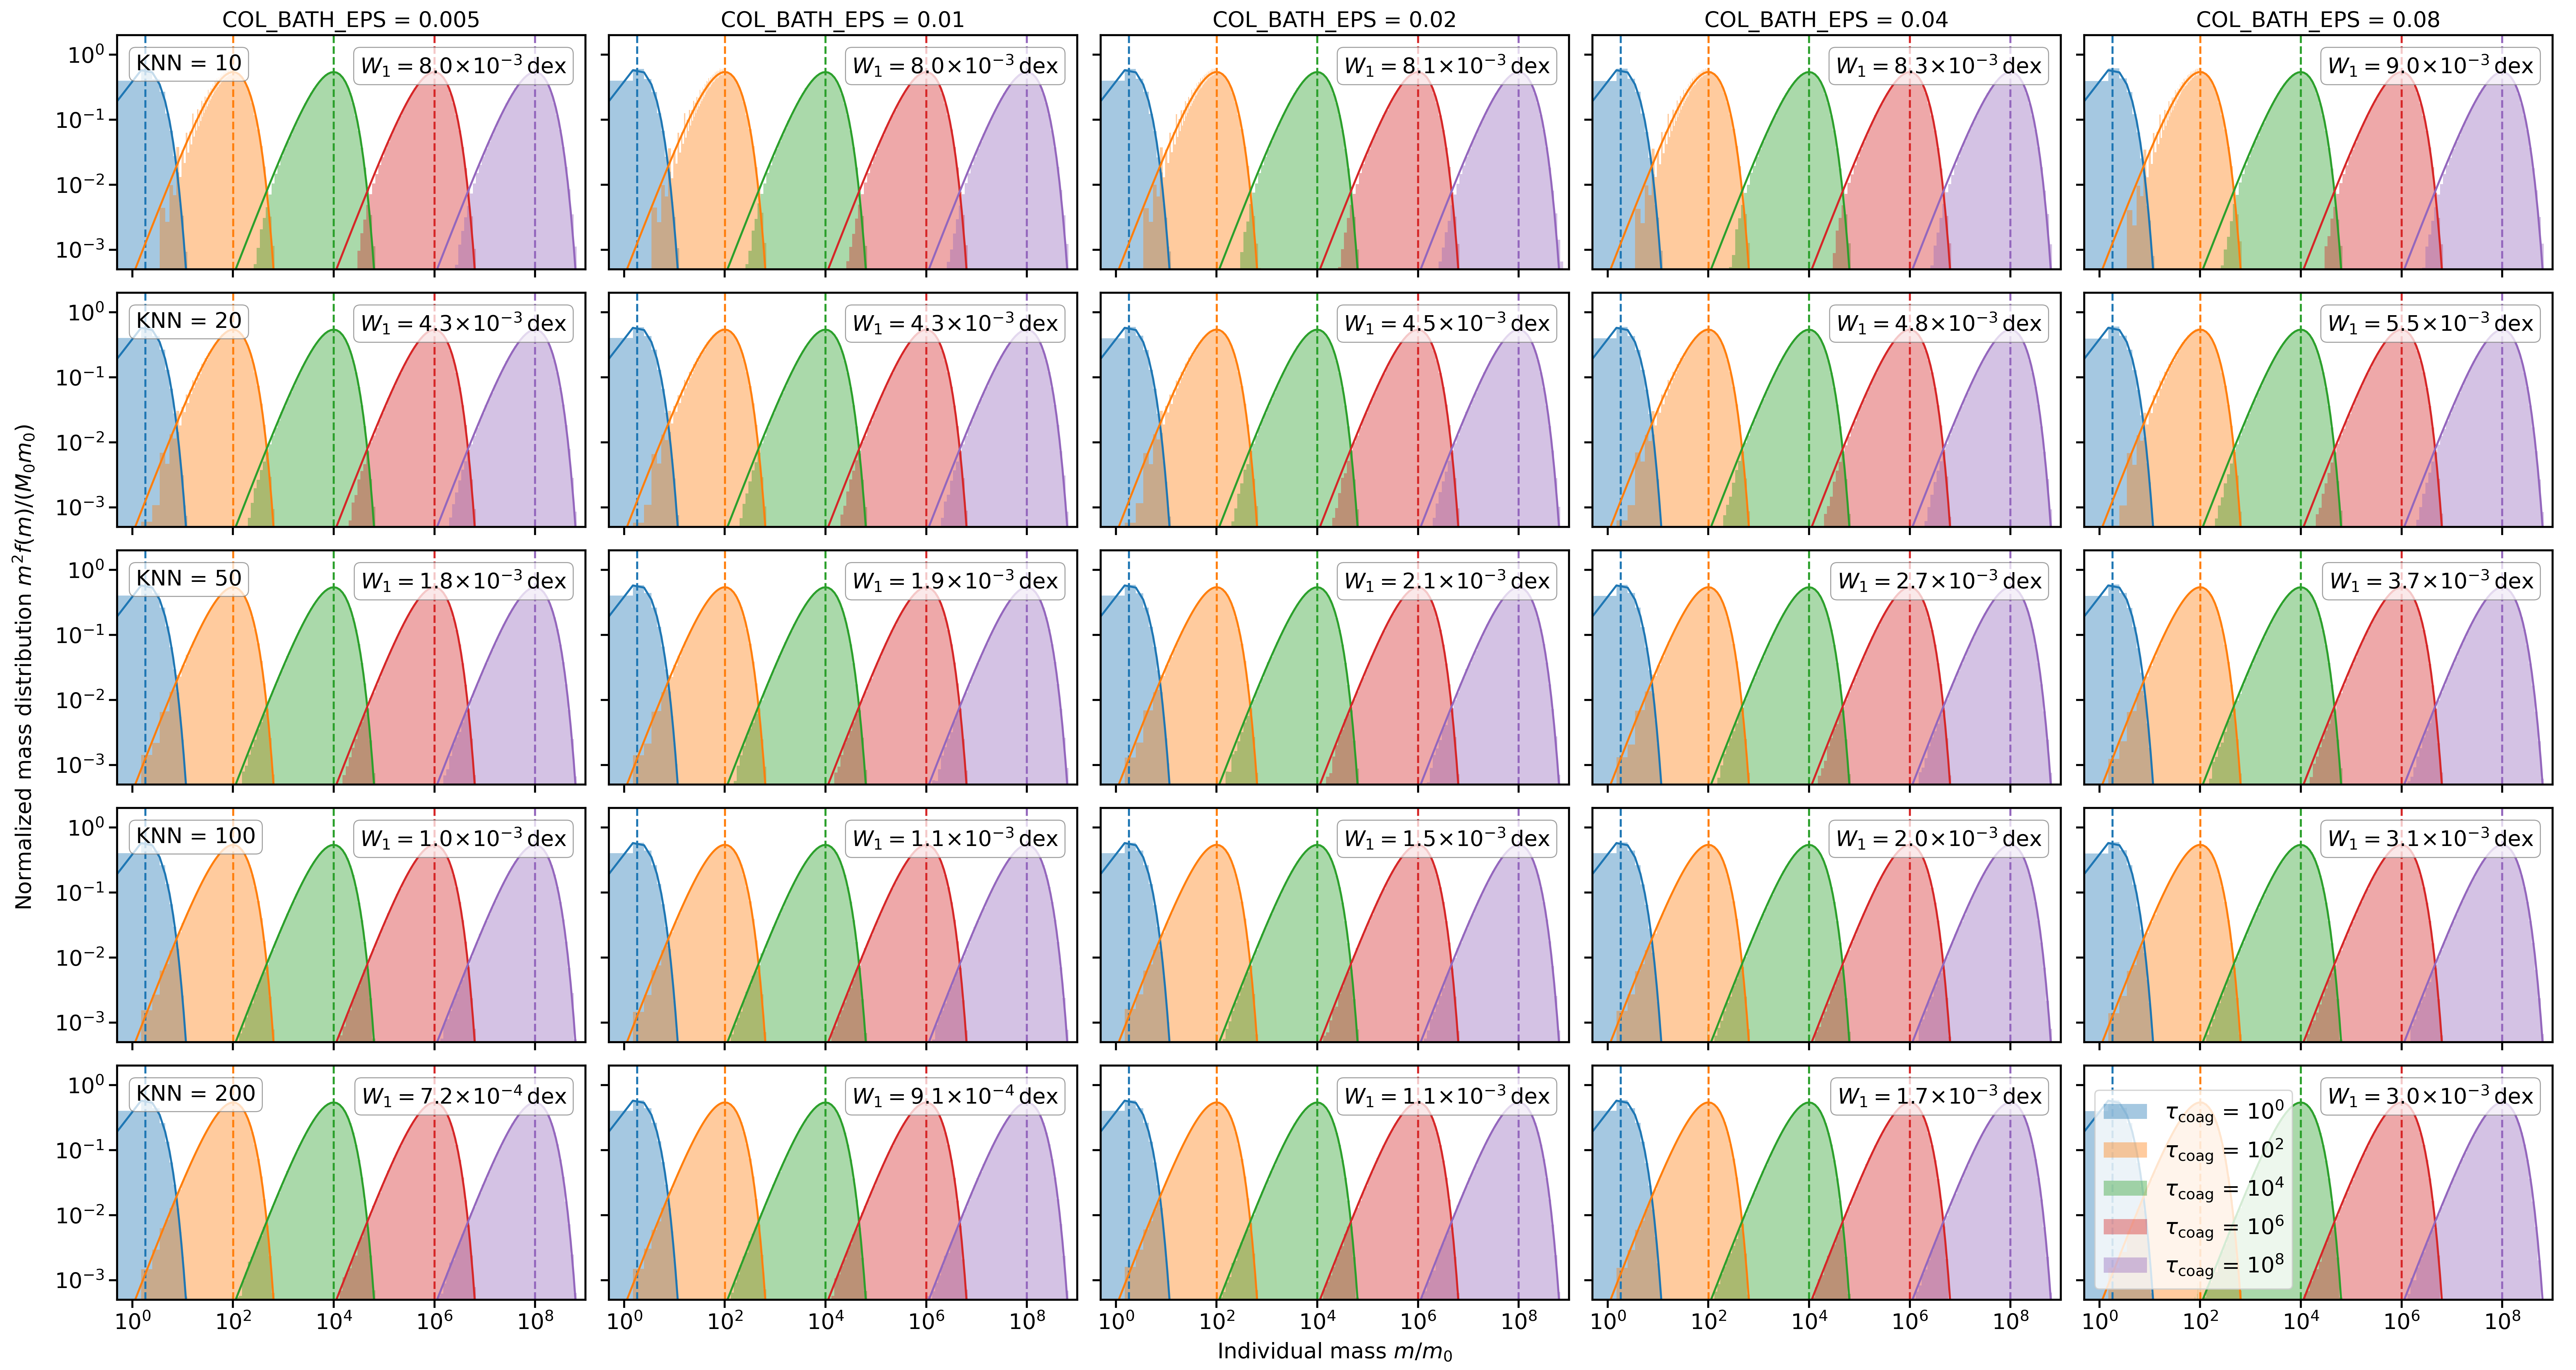

In [162]:
# const kernel

k_values   = ['1e+1', '2e+1', '5e+1', '1e+2', '2e+2']
b_values   = ['5e-3', '1e-2', '2e-2', '4e-2', '8e-2']
model_list = ['1e+6n_{}k_{}b'.format(k, b) for k, b in product(k_values, b_values)]

# model_ref = '1e+6n_5e+1k_2e-2b'
# with Path('/Users/jiaqingbi/Scratch/gamedev/test_const/wall_time_summary.json').open() as file: timing = json.load(file)
# wall_time = {entry['model']: entry['wall_seconds'] for entry in timing['models']}
# err_level = {model: model_w1_const(model) for model in model_list}
# err_level_ref = err_level[model_ref]
# wall_time_ref = wall_time[model_ref]

summary_path = Path('/Users/jiaqingbi/Documents/research/gamedev/val/logs/coagulation/test_const/multiseed/summary.json')
with summary_path.open() as file: summary = json.load(file)
model_stats = {entry['model']: entry for entry in summary['models']}
err_level = {model: model_stats[model]['scores']['w1_log10_mass_dex']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.36
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_const/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-1, 1e9
    y_min, y_max = 5e-4, 2e0

    k_switch = 100
    integer_edges = np.arange(0.5, k_switch + 1.5, 1.0)
    log_edges = np.geomspace(integer_edges[-1], x_max, 120)
    x_bins = np.concatenate([integer_edges, log_edges[1:]])

    # x_bins = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    xticks = [1e0, 1e2, 1e4, 1e6, 1e8]
    xtick_labels = ['$10^{:d}$'.format(int(np.log10(x))) for x in xticks]

    idx_file = [1,3,5,7,9]
    for i, snapshot in enumerate(idx_file):

        time = 10**(snapshot - 1)
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        g = 1.0 / (1.0 + 0.5*time)
        mu_peak = -2.0 / np.log1p(-g)
        axs[idx_mod].axvline(x = mu_peak, ls = '--', color = f'C{i}', lw = linewidth)
        axs[idx_mod].plot(x_bins, const_kernel(x_bins, N_0, M_0, m_0, lambda_0, time), color = f'C{i}', lw = linewidth)

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(
            hist[0] / np.diff(np.log(x_bins)), hist[1], fill = 1, alpha = 0.4,
            color = f'C{i}', label = f'$\\tau_\\mathrm{{coag}}$ = $10^{snapshot - 1:d}$'
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right',
    )

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize)

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, 'KNN = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'left'
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('COL_BATH_EPS = {}'.format(eps), fontsize = fontsize)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()

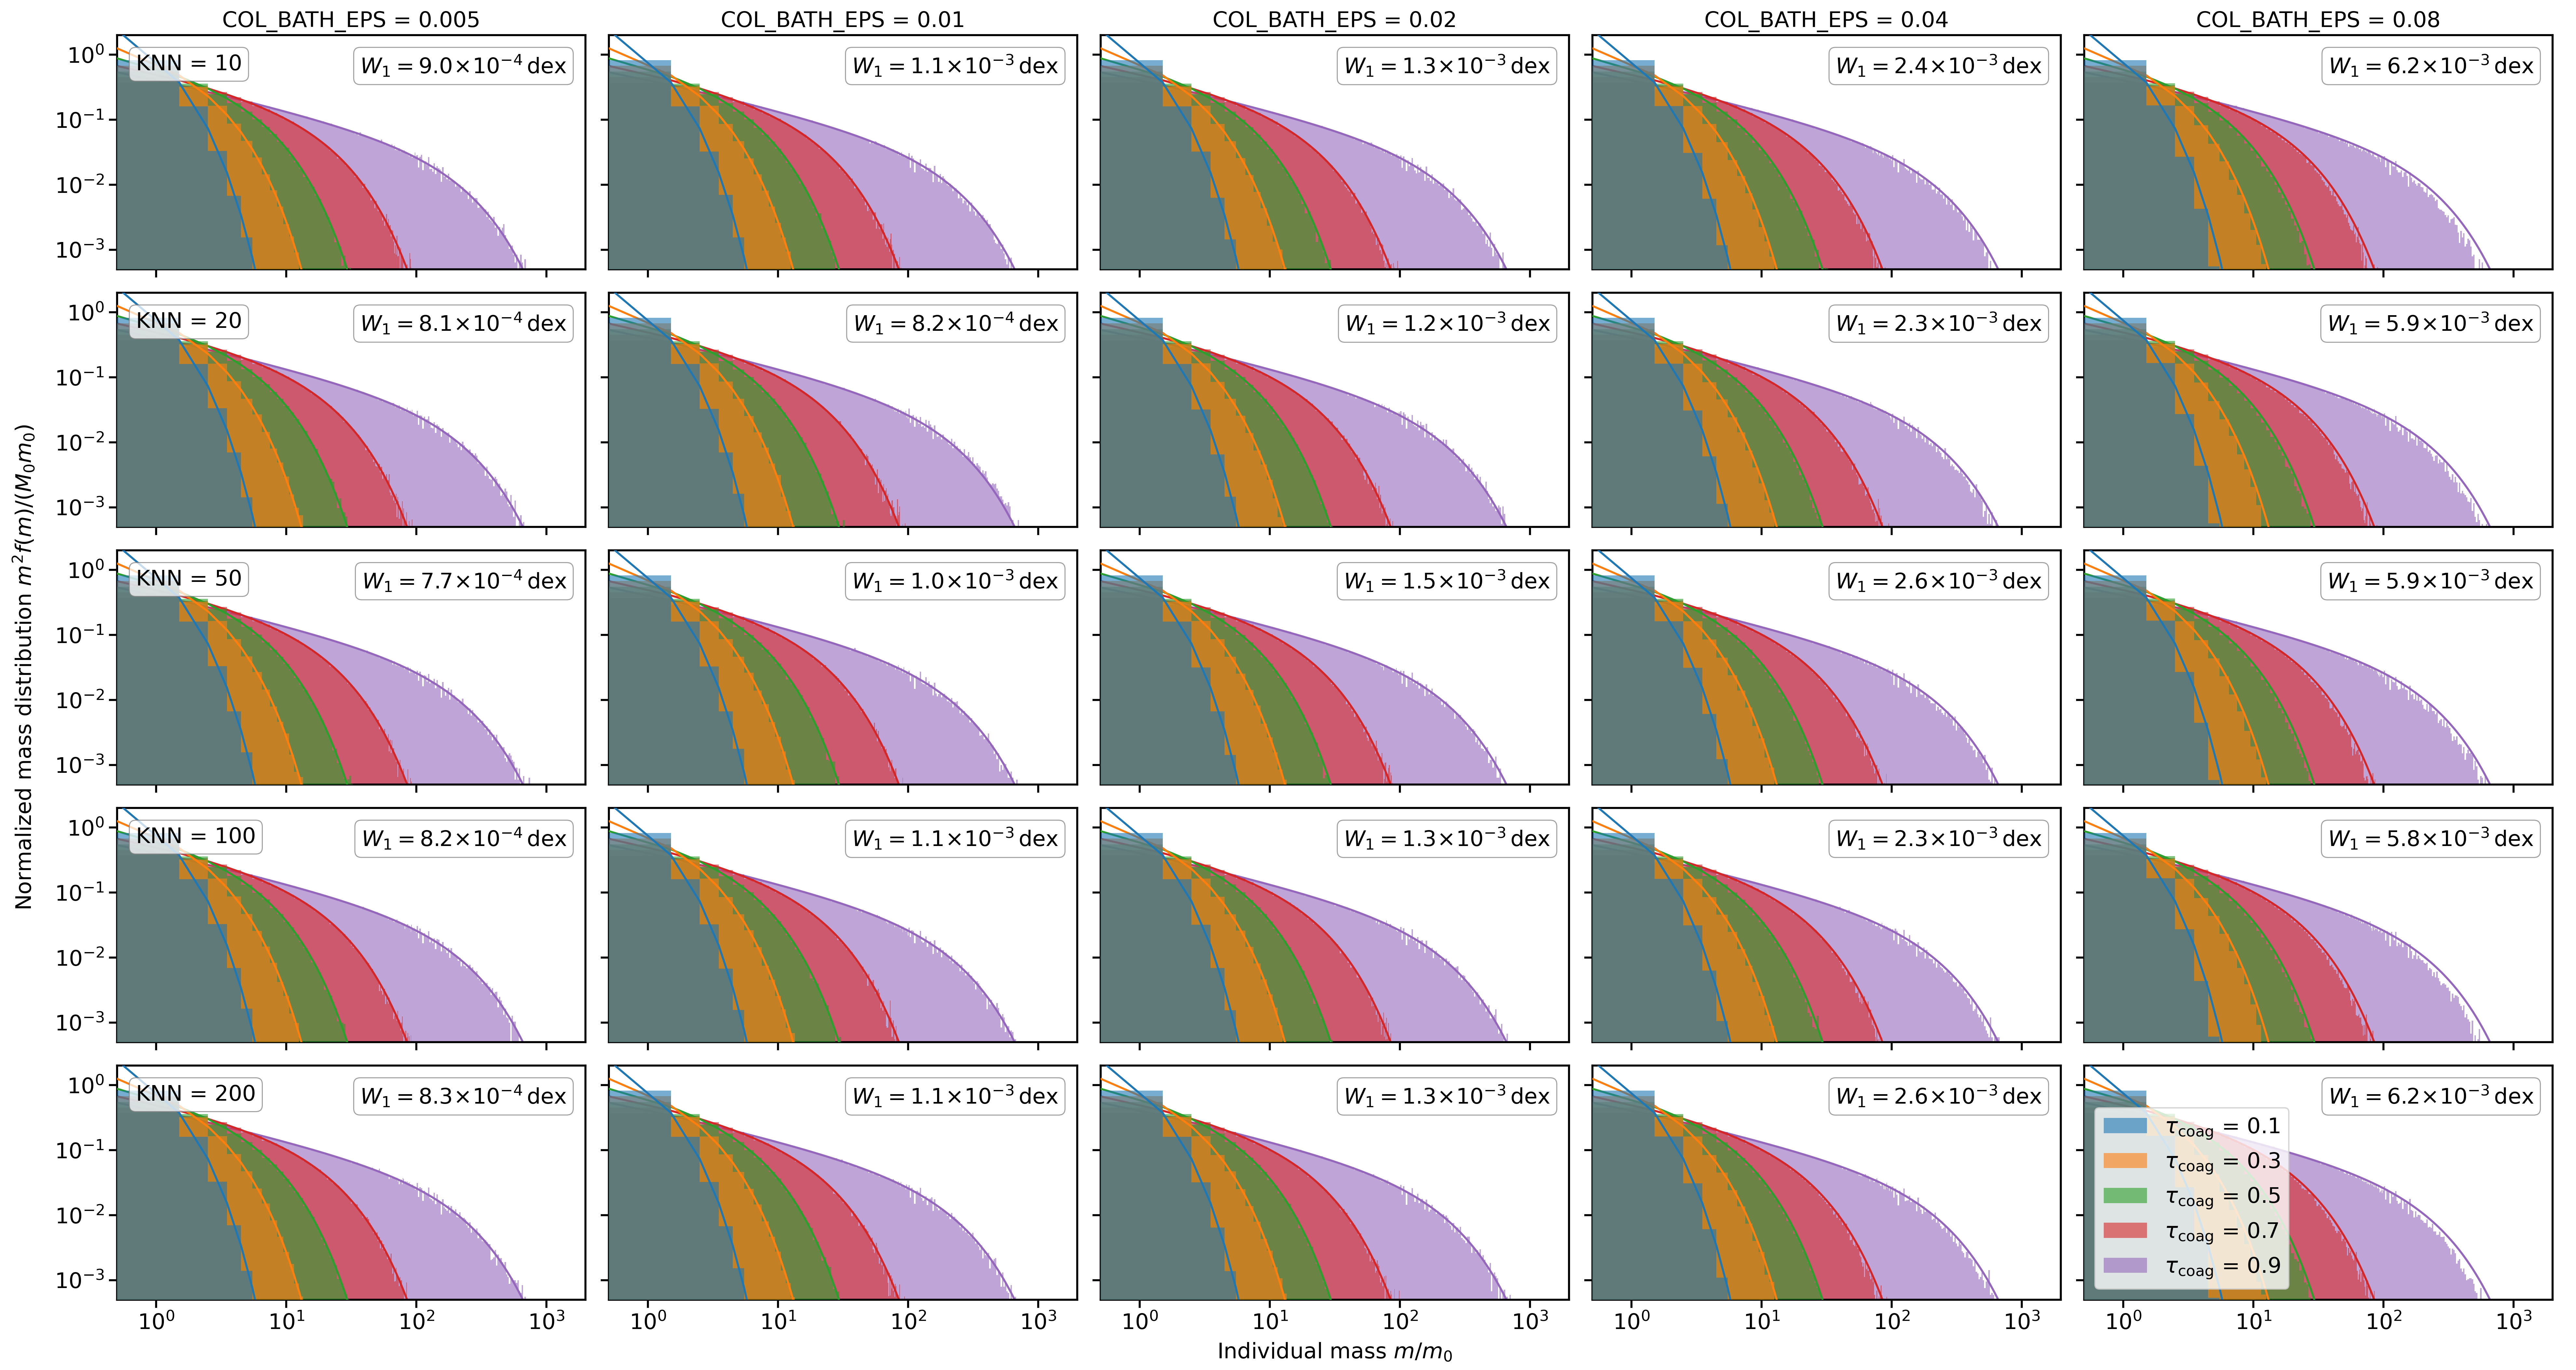

In [163]:
# product kernel

k_values   = ['1e+1', '2e+1', '5e+1', '1e+2', '2e+2']
b_values   = ['5e-3', '1e-2', '2e-2', '4e-2', '8e-2']
model_list = ['1e+6n_{}k_{}b'.format(k, b) for k, b in product(k_values, b_values)]

# model_ref = '1e+6n_5e+1k_2e-2b'
# with Path('/Users/jiaqingbi/Scratch/gamedev/test_product/wall_time_summary.json').open() as file: timing = json.load(file)
# wall_time = {entry['model']: entry['wall_seconds'] for entry in timing['models']}
# err_level = {model: model_w1_product(model) for model in model_list}
# err_level_ref = err_level[model_ref]
# wall_time_ref = wall_time[model_ref]

summary_path = Path('/Users/jiaqingbi/Documents/research/gamedev/val/logs/coagulation/test_product/multiseed/summary.json')
with summary_path.open() as file: summary = json.load(file)
model_stats = {entry['model']: entry for entry in summary['models']}
err_level = {model: model_stats[model]['scores']['w1_log10_mass_dex']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.36
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_product/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-1, 2e3
    y_min, y_max = 5e-4, 2e0

    k_switch = 100
    integer_edges = np.arange(0.5, k_switch + 1.5, 1.0)
    log_edges = np.geomspace(integer_edges[-1], x_max, 120)
    x_bins = np.concatenate([integer_edges, log_edges[1:]])

    xticks = [1e0, 1e1, 1e2, 1e3]
    xtick_labels = ['$10^{:d}$'.format(int(np.log10(x))) for x in xticks]

    idx_file = [1,3,5,7,9]
    for i, snapshot in enumerate(idx_file):

        time = float(config["PARAMETERS"]["DT_OUT"])*snapshot
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        axs[idx_mod].plot(x_bins, product_kernel(x_bins, N_0, M_0, m_0, lambda_0, time), color = f'C{i}', lw = linewidth, zorder = len(idx_file) - i)

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(
            hist[0] / np.diff(np.log(x_bins)), hist[1], fill = 1, alpha = 0.6, color = f'C{i}', 
            label = f'$\\tau_\\mathrm{{coag}}$ = {time:.1f}', zorder = len(idx_file) - i
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].xaxis.set_minor_locator(NullLocator())
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right',
    )

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize)

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, 'KNN = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'left', zorder = 10
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('COL_BATH_EPS = {}'.format(eps), fontsize = fontsize)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()

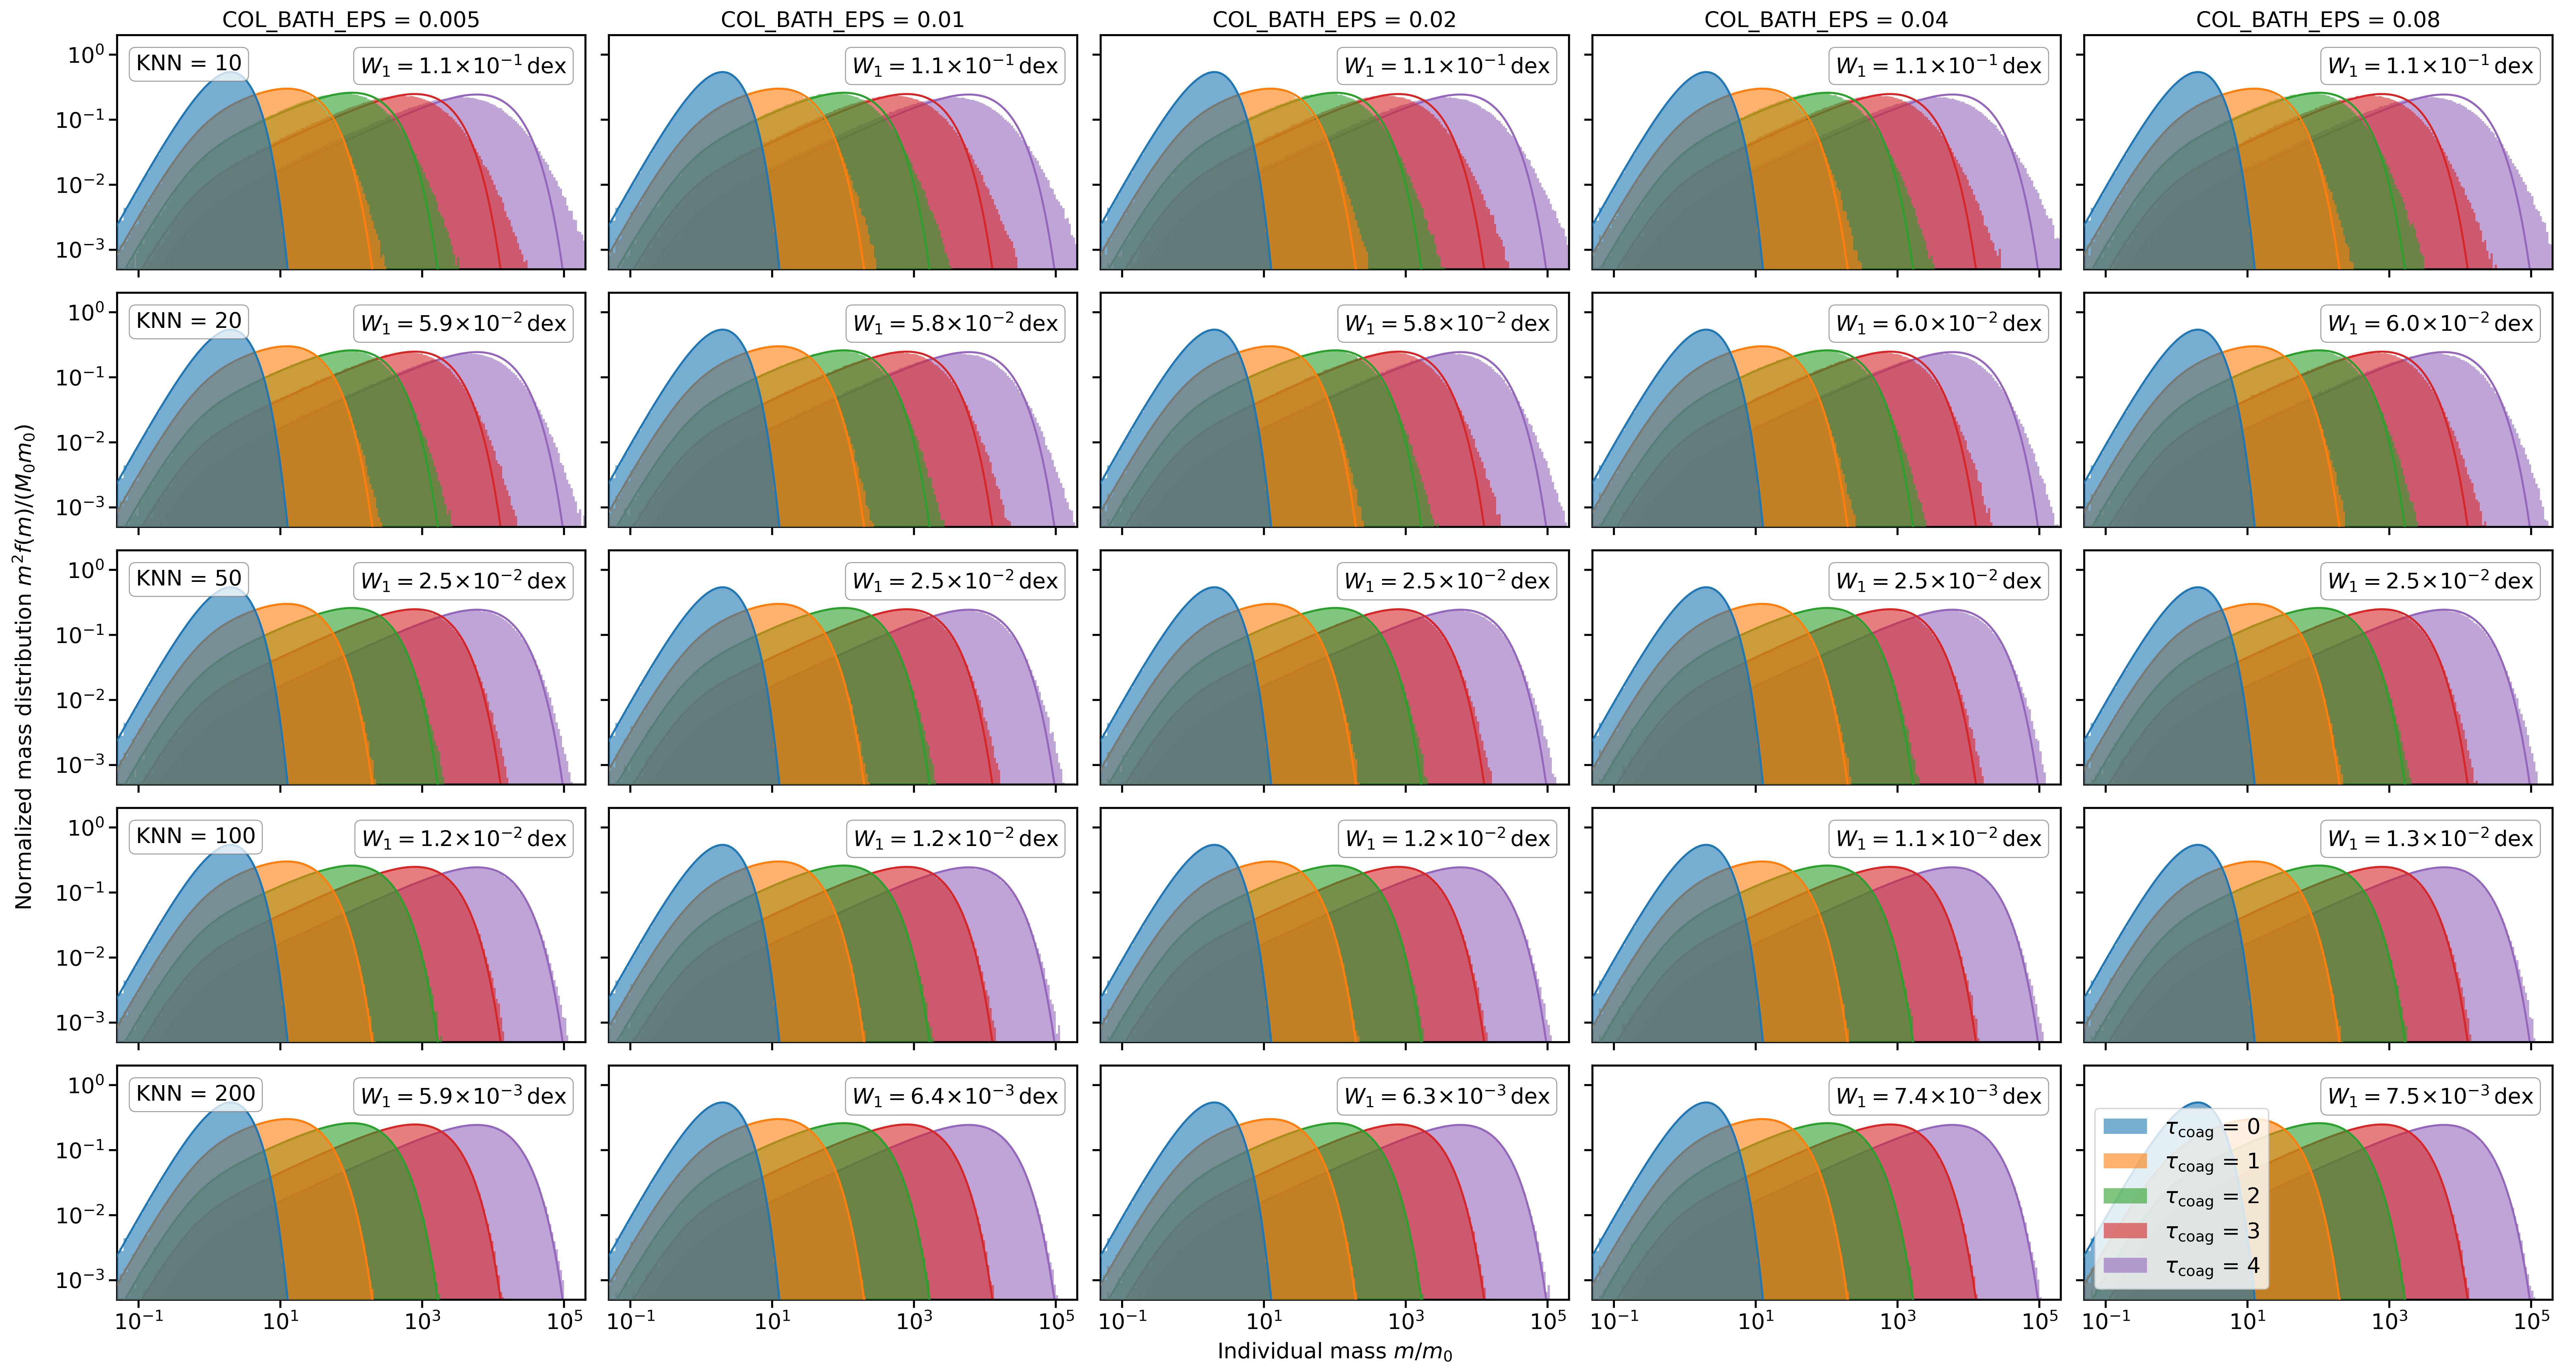

In [161]:
# linear kernel

k_values   = ['1e+1', '2e+1', '5e+1', '1e+2', '2e+2']
b_values   = ['5e-3', '1e-2', '2e-2', '4e-2', '8e-2']
model_list = ['1e+6n_{}k_{}b'.format(k, b) for k, b in product(k_values, b_values)]

# model_ref = '1e+6n_5e+1k_2e-2b'
# with Path('/Users/jiaqingbi/Scratch/gamedev/test_linear/wall_time_summary.json').open() as file: timing = json.load(file)
# wall_time = {entry['model']: entry['wall_seconds'] for entry in timing['models']}
err_level = {model: model_w1_linear(model) for model in model_list}
# err_level_ref = err_level[model_ref]
# wall_time_ref = wall_time[model_ref]

# summary_path = Path('/Users/jiaqingbi/Documents/research/gamedev/val/logs/coagulation/test_linear/multiseed/summary.json')
# with summary_path.open() as file: summary = json.load(file)
# model_stats = {entry['model']: entry for entry in summary['models']}
# err_level = {model: model_stats[model]['scores']['w1_log10_mass_dex']['mean'] for model in model_list}

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.36
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_linear/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-2, 2e5
    y_min, y_max = 5e-4, 2e0
    x_bins = np.geomspace(x_min, x_max, 220)

    xticks = [1e-1, 1e1, 1e3, 1e5]
    xtick_labels = ['$10^{{{:d}}}$'.format(int(np.log10(x))) for x in xticks]

    idx_file = [0,1,2,3,4]
    for i, snapshot in enumerate(idx_file):

        time = float(config["PARAMETERS"]["DT_OUT"])*snapshot
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        analytic = init_dist(m_0*x_bins, N_0, M_0, m_0) if snapshot == 0 else linear_kernel(m_0*x_bins, N_0, M_0, m_0, lambda_0, time)
        axs[idx_mod].plot(x_bins, analytic, color = f'C{i}', lw = linewidth, zorder = len(idx_file) - i)

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(
            hist[0] / np.diff(np.log(x_bins)), hist[1], fill = 1, alpha = 0.6, color = f'C{i}', 
            label = f'$\\tau_\\mathrm{{coag}}$ = {time:.0f}', zorder = len(idx_file) - i
        )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].xaxis.set_minor_locator(NullLocator())
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    base, expo = f'{err_level[model]:.1e}'.split('e')
    axs[idx_mod].text(0.96, 0.92, rf'$W_1 = {float(base):.1f}\!\times\!10^{{{int(expo)}}}\,\mathrm{{dex}}$',
        bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
        transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'right',
    )

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize)

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, 'KNN = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = 0.5*linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'left', zorder = 10
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('COL_BATH_EPS = {}'.format(eps), fontsize = fontsize)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()